# Analyse Pareto
on analyse les resultat de l'algorithm NSGA-II
les deux objectives de l'optimisation sont : 
maximiser la precision de la classification 
minimiser le nombre de parametre du modele

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Importation des données

In [2]:
log_path = r'C:\Users\mohamedamine.laaraj\Documents\resultat_optim.txt'  

pattern = re.compile(
    r"Trial (\d+) finished with values: \[([\d.]+), ([\d.]+)\] and parameters: (\{.*?\})"
)

rows = []
with open(log_path) as f:
    for line in f:
        m = pattern.search(line)
        if m:
            trial_id  = int(m.group(1))
            accuracy  = float(m.group(2))
            n_params  = float(m.group(3))
            params    = eval(m.group(4))   
            rows.append({
                'trial':      trial_id,
                'accuracy':   accuracy,
                'n_params':   n_params,
                'n_layers':   params.get('n_layers'),
                'activation': params.get('activation'),
                'dropout':    params.get('dropout_rate'),
                'lr':         params.get('lr'),
                'epochs':     params.get('epochs'),
                'batch_size': params.get('batch_size'),
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} trials")
df.head()

Loaded 60 trials


,trial,accuracy,n_params,n_layers,activation,dropout,lr,epochs,batch_size
0,0,0.441167,6863211.0,3,leaky_relu,0.348813,0.002512,32,32
1,1,0.433344,1975147.0,1,relu,0.102113,0.000573,33,64
2,2,0.480603,989547.0,1,leaky_relu,0.146397,0.003902,40,16
3,3,0.468291,7121003.0,2,leaky_relu,0.343738,0.002747,43,16
4,4,0.437256,1975147.0,1,tanh,0.362149,0.007405,48,16


## Fronte de Pareto

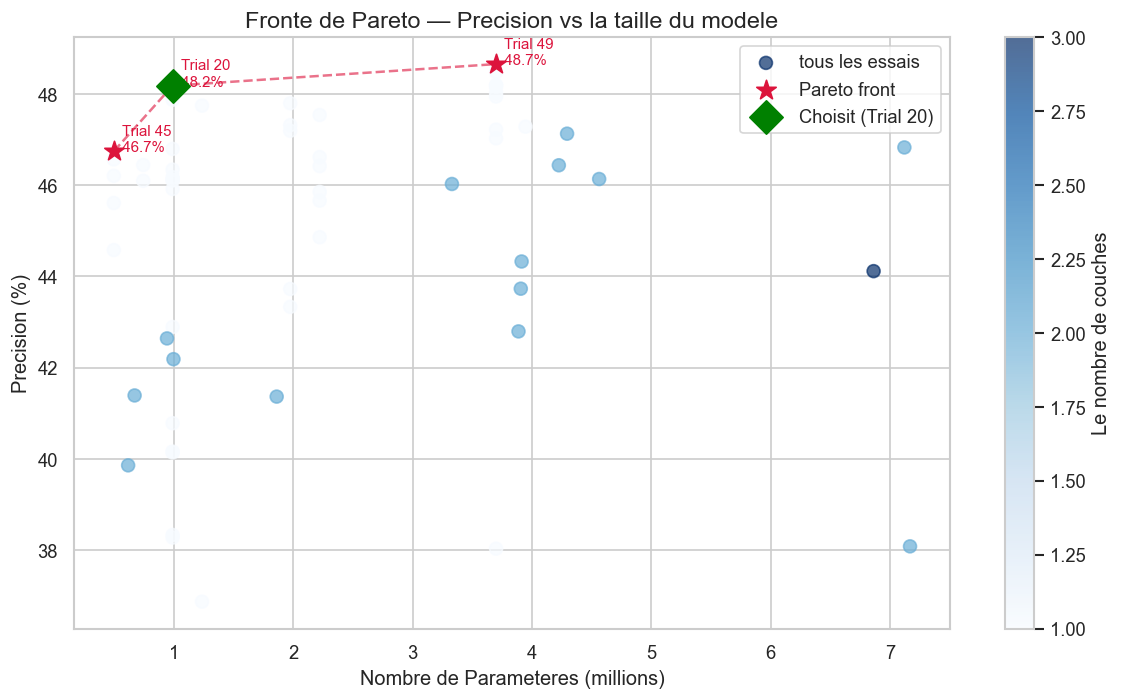

In [4]:

pareto_ids = [20, 45, 49]
df['on_pareto'] = df['trial'].isin(pareto_ids)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df[~df['on_pareto']]['n_params'] / 1e6,
    df[~df['on_pareto']]['accuracy'] * 100,
    c=df[~df['on_pareto']]['n_layers'],
    cmap='Blues', alpha=0.7, s=60, label='tous les essais'
)

pareto_df = df[df['on_pareto']].sort_values('n_params')
ax.scatter(
    pareto_df['n_params'] / 1e6,
    pareto_df['accuracy'] * 100,
    color='crimson', s=150, zorder=5, marker='*', label='Pareto front'
)

ax.plot(
    pareto_df['n_params'] / 1e6,
    pareto_df['accuracy'] * 100,
    color='crimson', linewidth=1.5, linestyle='--', alpha=0.6
)

for _, row in pareto_df.iterrows():
    ax.annotate(
        f"  Trial {int(row['trial'])}\n  {row['accuracy']*100:.1f}%",
        (row['n_params'] / 1e6, row['accuracy'] * 100),
        fontsize=9, color='crimson'
    )

chosen = df[df['trial'] == 20].iloc[0]
ax.scatter(
    chosen['n_params'] / 1e6, chosen['accuracy'] * 100,
    color='green', s=200, zorder=6, marker='D', label='Choisit (Trial 20)'
)

plt.colorbar(scatter, ax=ax, label='Le nombre de couches')
ax.set_xlabel('Nombre de Parameteres (millions)', fontsize=12)
ax.set_ylabel('Precision (%)', fontsize=12)
ax.set_title('Fronte de Pareto — Precision vs la taille du modele', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('pareto_front.png', dpi=150)
plt.show()

## précision au fil des essais

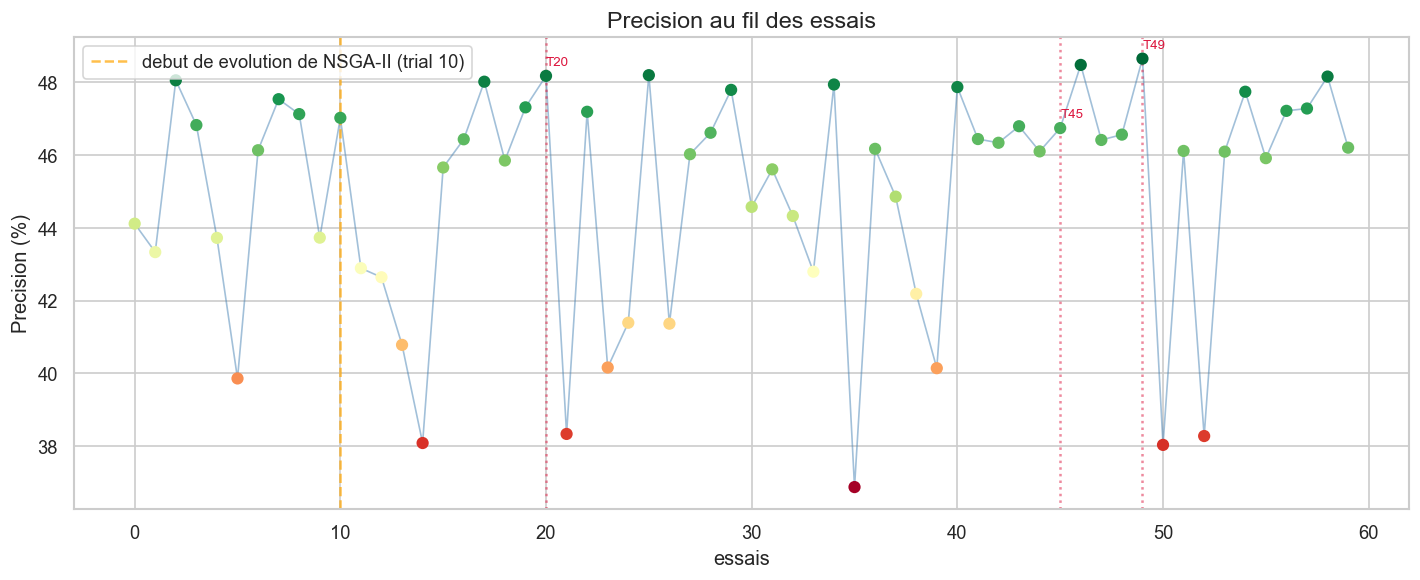

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['trial'], df['accuracy'] * 100, alpha=0.5, color='steelblue', linewidth=1)
ax.scatter(df['trial'], df['accuracy'] * 100, c=df['accuracy'], cmap='RdYlGn', s=40, zorder=3)

for pid in pareto_ids:
    row = df[df['trial'] == pid].iloc[0]
    ax.axvline(x=pid, color='crimson', linestyle=':', alpha=0.5)
    ax.annotate(f"T{pid}", (pid, row['accuracy']*100 + 0.3), color='crimson', fontsize=8)

ax.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='debut de evolution de NSGA-II (trial 10)')

ax.set_xlabel('essais', fontsize=12)
ax.set_ylabel('Precision (%)', fontsize=12)
ax.set_title('Precision au fil des essais', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('accuracy_over_trials.png', dpi=150)
plt.show()

## Analyse des fonctions d'activation

C:\Users\mohamedamine.laaraj\AppData\Local\Temp\ipykernel_22284\585636292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


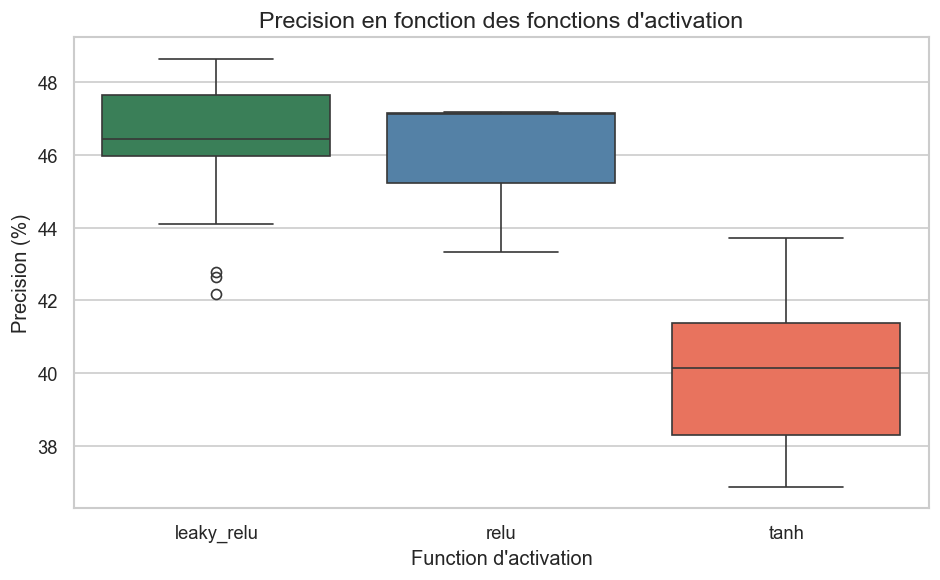

             mean    max  count
activation                     
leaky_relu  46.42  48.66   4300
relu        45.89  47.19    300
tanh        40.26  43.73   1400


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df, x='activation', y=df['accuracy']*100,
    palette={'relu': 'steelblue', 'leaky_relu': 'seagreen', 'tanh': 'tomato'},
    ax=ax
)
ax.set_xlabel("Function d'activation", fontsize=12)
ax.set_ylabel('Precision (%)', fontsize=12)
ax.set_title("Precision en fonction des fonctions d'activation", fontsize=14)
plt.tight_layout()
plt.savefig('activation_analysis.png', dpi=150)
plt.show()

print(df.groupby('activation')['accuracy'].agg(['mean','max','count']).round(4) * 100)

## Analyse de nombre de couches

C:\Users\mohamedamine.laaraj\AppData\Local\Temp\ipykernel_22284\868830975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='n_layers', y=df['accuracy']*100, palette='Blues', ax=ax)


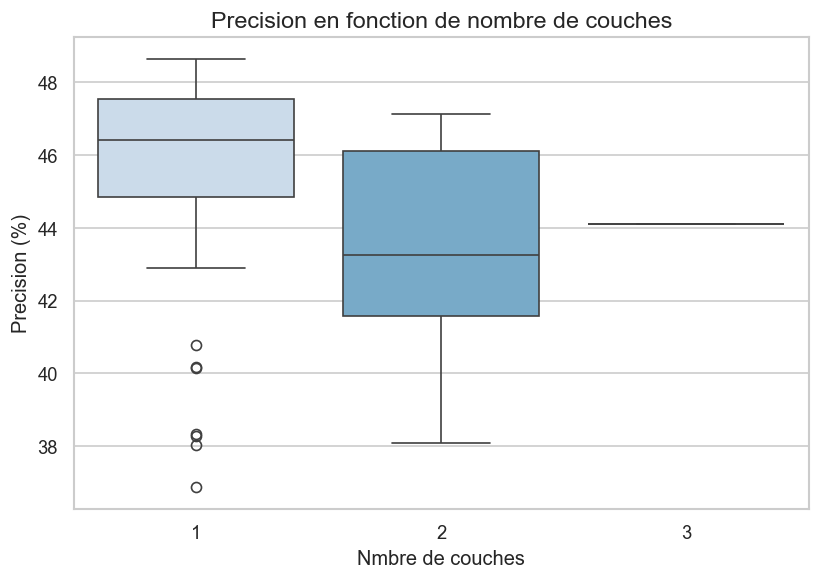

           mean    max  count
n_layers                     
1         45.43  48.66   4500
2         43.50  47.13   1400
3         44.12  44.12    100


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='n_layers', y=df['accuracy']*100, palette='Blues', ax=ax)
ax.set_xlabel('Nmbre de couches', fontsize=12)
ax.set_ylabel('Precision (%)', fontsize=12)
ax.set_title('Precision en fonction de nombre de couches', fontsize=14)
plt.tight_layout()
plt.savefig('layers_analysis.png', dpi=150)
plt.show()

print(df.groupby('n_layers')['accuracy'].agg(['mean','max','count']).round(4) * 100)

## Sommaire de la fronte de pareto et decision finale

In [10]:
pareto_summary = df[df['on_pareto']][['trial','accuracy','n_params','activation','n_layers','dropout','lr']].copy()
pareto_summary['accuracy_%'] = (pareto_summary['accuracy'] * 100).round(2)
pareto_summary['n_params_M'] = (pareto_summary['n_params'] / 1e6).round(3)
pareto_summary['acc_per_Mparam'] = (pareto_summary['accuracy_%'] / pareto_summary['n_params_M']).round(2)

display(pareto_summary[['trial','accuracy_%','n_params_M','acc_per_Mparam','activation','n_layers','dropout','lr']])

print("\n→ essai choisi: 20")
print("  Raison: la meilleure precision comparer a la taille (48.18% at 0.99M params)")
print("  essai 49 gagne juste +0.48% de la precision pour plus de 3.7x en parametres")
print("  essai 45 est dominée par essai 20 au deux objectives.")

,trial,accuracy_%,n_params_M,acc_per_Mparam,activation,n_layers,dropout,lr
20,20,48.18,0.990,48.67,leaky_relu,1,0.146397,0.003902
45,45,46.75,0.497,94.06,leaky_relu,1,0.244662,0.002512
49,49,48.66,3.700,13.15,leaky_relu,1,0.362149,0.001230



→ essai choisi: 20
  Raison: la meilleure precision comparer a la taille (48.18% at 0.99M params)
  essai 49 gagne juste +0.48% de la precision pour plus de 3.7x en parametres
  essai 45 est dominée par essai 20 au deux objectives.
